# 01 — VAE Implementation, Step by Step

## 📚 Learning Objectives

By completing this notebook, you will:
- Implement every piece of a VAE for images: encoder, μ/log σ² heads, reparameterization, decoder, ELBO loss
- Train it on MNIST and verify it with **reconstructions**
- **Sample** novel images from the prior and **interpolate** between two real digits in latent space
- Apply the trained pattern to a production task: **anomaly detection** by reconstruction error

## 🔗 Where this fits

**Builds on:** Course 10 — Unit 1, lessons 04 and 12 (the VAE and its latent space) and Course 08 (AIAT 122) — Unit 2, whose convolutional layers this image VAE uses.

**Used later in:** Course 10 — Unit 3, lessons 02-03, which apply and extend this exact architecture.

---

## The Five Pieces of a VAE

1. **Encoder** — a network mapping an image to hidden features.
2. **Two heads** — `mu` and `logvar` layers: each image becomes a *Gaussian* q(z|x), not a point. This is what makes the autoencoder "variational".
3. **Reparameterization** — `z = μ + σ·ε, ε~N(0,1)`: sampling written so gradients flow through μ and σ.
4. **Decoder** — latent vector back to an image; Sigmoid output for [0,1] pixels.
5. **ELBO loss** — per-pixel binary cross-entropy (reconstruction) **+** KL(q(z|x) ‖ N(0,I)) (keeps latent space organized and sampleable).

Find each numbered piece in the code below.

---

## 🌍 Why this lesson exists — the VAE inside Stable Diffusion

The five pieces you are about to build are a shipping component of the most widely downloaded open image generator. Stable Diffusion does **not** run diffusion on pixels: Rombach et al. (2022, arXiv 2112.10752) run it inside a VAE latent space, compressing a 512×512×3 image (786,432 numbers) into a 64×64×4 latent (16,384 numbers) — a **48× reduction**. That compression is the reason text-to-image runs on a consumer GPU instead of a datacentre. The encoder/decoder pair is exactly the architecture below, scaled up and trained on photographs.

**What goes wrong without this:** drop the KL term and you have an ordinary autoencoder — a set of isolated points in latent space. You can compress and reconstruct, but you cannot sample, you cannot interpolate, and there is no continuous space for a diffusion model to operate inside. The KL term is what turns a compressor into a generator.


In [1]:
# WHAT/WHY: build the five VAE pieces and train on MNIST (all ten classes),
# printing the two loss components so you can watch reconstruction and KL
# trade off during training.
import torch, torch.nn as nn, torch.nn.functional as F, torch.optim as optim
import torchvision, torchvision.transforms as T
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
LATENT = 16; BATCH = 128; EPOCHS = 6

dataset = torchvision.datasets.MNIST('/tmp/mnist', train=True, download=True, transform=T.ToTensor())
subset  = torch.utils.data.Subset(dataset, range(12_800))
loader  = torch.utils.data.DataLoader(subset, batch_size=BATCH, shuffle=True)

class VAE(nn.Module):
    def __init__(self, z=16):
        super().__init__()
        # Encoder: image → hidden features → two heads (mean, log-variance)
        self.enc_fc = nn.Sequential(nn.Flatten(), nn.Linear(784, 256), nn.ReLU())
        self.mu     = nn.Linear(256, z)
        self.logvar = nn.Linear(256, z)
        # Decoder: latent vector → image (Sigmoid keeps pixels in [0, 1])
        self.dec_fc = nn.Sequential(nn.Linear(z, 256), nn.ReLU(),
                                    nn.Linear(256, 784), nn.Sigmoid())
    def encode(self, x):
        h = self.enc_fc(x)
        return self.mu(h), self.logvar(h)
    def reparameterise(self, mu, lv):
        # z = mu + sigma*eps: sampling that gradients can flow through
        return mu + (0.5 * lv).exp() * torch.randn_like(mu)
    def decode(self, z):
        return self.dec_fc(z).view(-1, 1, 28, 28)
    def forward(self, x):
        mu, lv = self.encode(x)
        z = self.reparameterise(mu, lv)
        return self.decode(z), mu, lv

model = VAE(z=LATENT)
opt   = optim.Adam(model.parameters(), lr=1e-3)

# WHAT/WHY: record the two loss components after every epoch, and decode the
# SAME eight latent codes each time, so the next cell can SHOW training as a
# curve and as a storyboard instead of only asserting it in printed numbers.
# The codes come from a SEPARATE generator, so the global random stream — and
# therefore every loss number printed below — is exactly what it was before.
snap_gen  = torch.Generator().manual_seed(123)
fixed_z   = torch.randn(8, LATENT, generator=snap_gen)
history   = []      # (epoch, recon, kl) after each epoch
snapshots = []      # those same eight latents, decoded after each epoch

# ── Training: minimize reconstruction BCE + KL divergence (the ELBO) ──────
for epoch in range(EPOCHS):
    recon_sum = kl_sum = 0.0
    for x, _ in loader:
        recon, mu, lv = model(x)
        recon_loss = F.binary_cross_entropy(recon, x, reduction='sum') / x.size(0)
        kl_loss    = -0.5 * torch.sum(1 + lv - mu.pow(2) - lv.exp()) / x.size(0)
        loss = recon_loss + kl_loss
        opt.zero_grad(); loss.backward(); opt.step()
        recon_sum += recon_loss.item(); kl_sum += kl_loss.item()
    n = len(loader)
    history.append((epoch + 1, recon_sum / n, kl_sum / n))
    with torch.no_grad():                      # snapshots never touch gradients
        snapshots.append(model.decode(fixed_z).squeeze(1).clone())
    print(f"Epoch {epoch+1}/{EPOCHS} — recon: {recon_sum/n:6.1f}   KL: {kl_sum/n:5.1f}   total: {(recon_sum+kl_sum)/n:6.1f}")
model.eval()
print("\nBoth components per image: reconstruction falls as the decoder improves;")
print("KL stays moderate — the regularizer holding the latent space near N(0, I).")


Epoch 1/6 — recon:  235.8   KL:  11.1   total:  246.9


Epoch 2/6 — recon:  161.0   KL:  13.1   total:  174.0


Epoch 3/6 — recon:  135.2   KL:  16.2   total:  151.3


Epoch 4/6 — recon:  121.5   KL:  18.2   total:  139.6


Epoch 5/6 — recon:  114.2   KL:  19.1   total:  133.3


Epoch 6/6 — recon:  109.5   KL:  19.5   total:  128.9

Both components per image: reconstruction falls as the decoder improves;
KL stays moderate — the regularizer holding the latent space near N(0, I).


## Watch the Trade-off Happen

The epoch log printed two numbers moving in opposite directions. Below they are drawn:
the reconstruction term and the KL term as curves, and — because a loss curve is not a
picture of a generator — the **same eight latent codes decoded after every epoch**, as a
storyboard and as an animation.

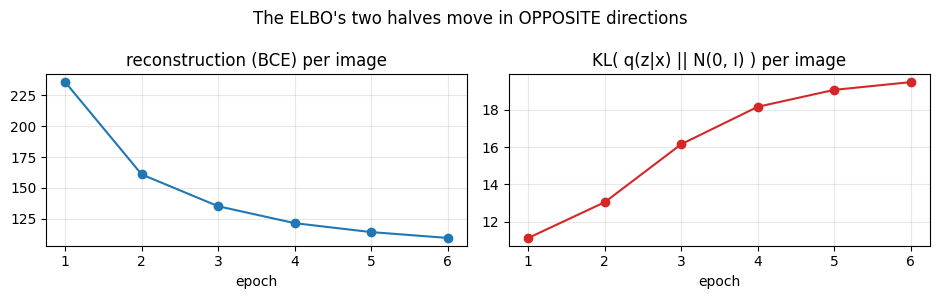

epoch    recon      KL    total
    1    235.8    11.1    246.9
    2    161.0    13.1    174.0
    3    135.2    16.2    151.3
    4    121.5    18.2    139.6
    5    114.2    19.1    133.3
    6    109.5    19.5    128.9

recon 235.8 -> 109.5 (down 54%)   |   KL 11.1 -> 19.5 (up 75%)


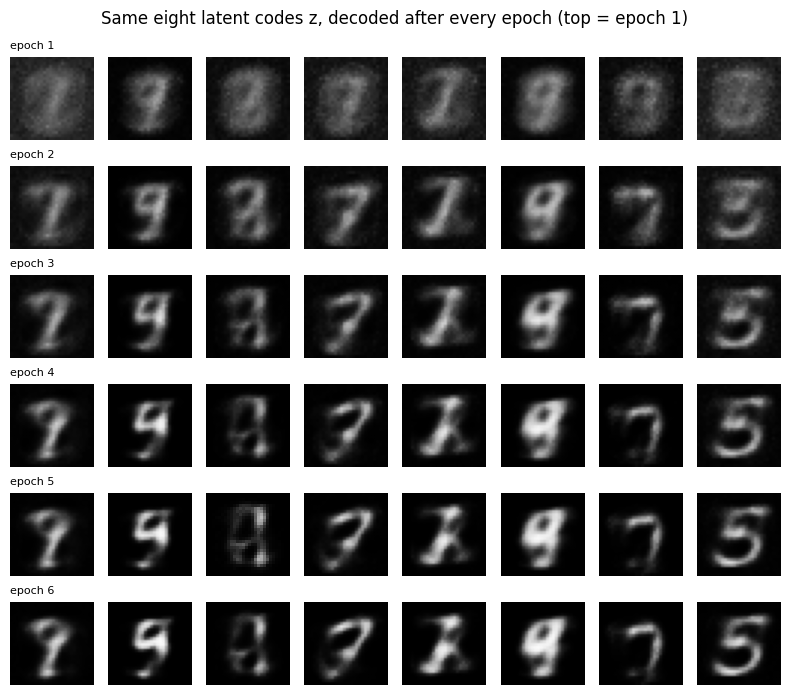

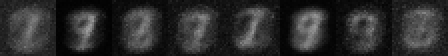

animation above: 6 frames, one per epoch, same z throughout.


In [2]:
# WHAT/WHY: the epoch log above asserts a trade-off; this cell draws it.
# (a) the two ELBO components as curves, (b) what the trade-off buys — the same
# eight latent codes decoded after every epoch, as a storyboard and as an
# animation. Everything here reuses the history recorded above: no extra
# training. The GIF helper is the idiom from Course 09's course09_step_viz
# (frames_to_gif_bytes / display_gif), kept inline so this notebook stands alone.
import io
from PIL import Image
from IPython.display import Image as IPyImage, display

ep    = [h[0] for h in history]
recon = [h[1] for h in history]
kl    = [h[2] for h in history]

# ── (a) the two halves of the ELBO, epoch by epoch ───────────────────────
fig, ax = plt.subplots(1, 2, figsize=(9.5, 3.0))
ax[0].plot(ep, recon, 'o-', color='tab:blue')
ax[0].set_title("reconstruction (BCE) per image"); ax[0].set_xlabel("epoch")
ax[0].grid(alpha=.3)
ax[1].plot(ep, kl, 'o-', color='tab:red')
ax[1].set_title("KL( q(z|x) || N(0, I) ) per image"); ax[1].set_xlabel("epoch")
ax[1].grid(alpha=.3)
plt.suptitle("The ELBO's two halves move in OPPOSITE directions")
plt.tight_layout(); plt.show()

# ── the same run as a step table ──────────────────────────────────
print(f"{'epoch':>5} {'recon':>8} {'KL':>7} {'total':>8}")
for e, r, k in history:
    print(f"{e:>5} {r:>8.1f} {k:>7.1f} {r + k:>8.1f}")
print(f"\nrecon {recon[0]:.1f} -> {recon[-1]:.1f} (down {100*(1-recon[-1]/recon[0]):.0f}%)"
      f"   |   KL {kl[0]:.1f} -> {kl[-1]:.1f} (up {100*(kl[-1]/kl[0]-1):.0f}%)")

# ── (b) storyboard: the SAME eight z vectors, decoded after each epoch ────
fig, axes = plt.subplots(len(snapshots), 8, figsize=(8, 1.18 * len(snapshots)))
for r, snap in enumerate(snapshots):
    for c_ in range(8):
        axes[r, c_].imshow(snap[c_], cmap='gray', vmin=0, vmax=1)
        axes[r, c_].axis('off')
    axes[r, 0].set_title(f"epoch {r+1}", loc='left', fontsize=8)
plt.suptitle("Same eight latent codes z, decoded after every epoch (top = epoch 1)")
plt.tight_layout(); plt.show()

# ── and as an animation: one frame per epoch ─────────────────────────
def frames_to_gif_bytes(frames, duration_ms=520):
    """Encode uint8 frames as one animated GIF (Course 09 course09_step_viz idiom)."""
    imgs = [Image.fromarray(np.asarray(f, dtype=np.uint8)) for f in frames]
    buf = io.BytesIO()
    imgs[0].save(buf, format="GIF", save_all=True, append_images=imgs[1:],
                 duration=duration_ms, loop=0)
    return buf.getvalue()

def display_gif(frames, duration_ms=520):
    display(IPyImage(data=frames_to_gif_bytes(frames, duration_ms), format="gif"))

# each frame = the eight decoded digits side by side, pixel-doubled to be readable
frames = [np.kron((np.concatenate(list(s.numpy()), axis=1) * 255).astype(np.uint8),
                  np.ones((2, 2), dtype=np.uint8)) for s in snapshots]
display_gif(frames)
print(f"animation above: {len(frames)} frames, one per epoch, same z throughout.")


### 👁️ Read the figures

**The curves.** Reconstruction falls 235.8 → 109.5 (−54%) while KL climbs 11.1 → 19.5 (+75%).
These are not two views of "the loss going down": the decoder is buying detail, and the KL
term is charging it. Read them as a pair — a KL curve that collapsed toward zero while
reconstruction kept improving would be posterior collapse (see *Where this breaks*), not a
better VAE.

**The storyboard and the animation.** Both show the *same* eight latent codes, decoded after
each epoch. Row 1 is fog — every column is a grey smear with at most a hint of a stroke. From
row 2 on, most columns lock onto an identity and keep it: column 2 is a 9, column 6 is a 9 and
column 7 is a 7 from epoch 2 all the way down, and what the later epochs buy them is stroke
definition, not a change of identity.

Two columns never resolve. Column 3 stays a smudged loop at every epoch, and column 5 stays an
ambiguous cross. A random z is not guaranteed to land on a clean digit, and no amount of extra
training fixes those particular samples. Column 8 is the counter-example to "identity is fixed
early": it reads as a 3 at epoch 2 and settles into a 5 from epoch 3 onward. The generator is
not "getting the right answer" — it is sharpening a map from z to image that was roughly in
place after two epochs.

## Using the Trained VAE: Reconstruct, Sample, Interpolate

The three standard checks, in one figure each:
- **Reconstruction** — encode + decode unseen test digits (top row real, bottom row reconstruction)
- **Sampling** — decode z ~ N(0, I): novel *samples*. Look at how many of them are actually recognisable digits — that number is the honest measure of this model.
- **Interpolation** — decode the straight line between two real digits' latent codes


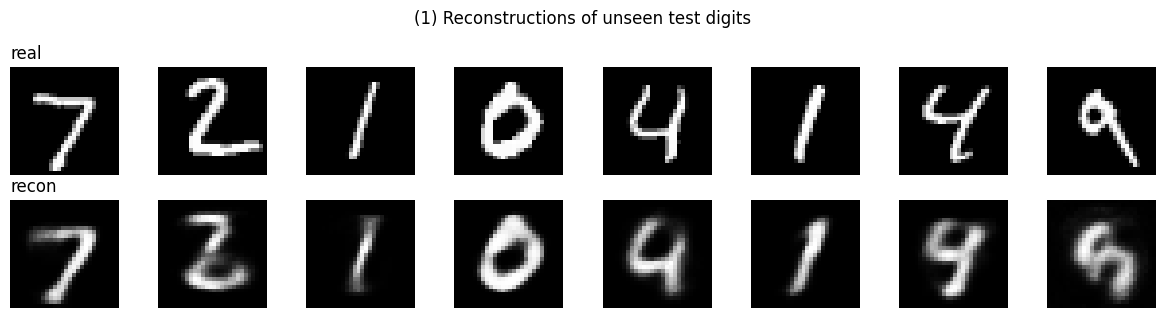

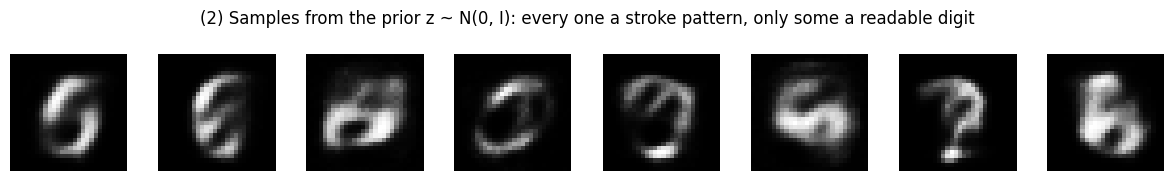

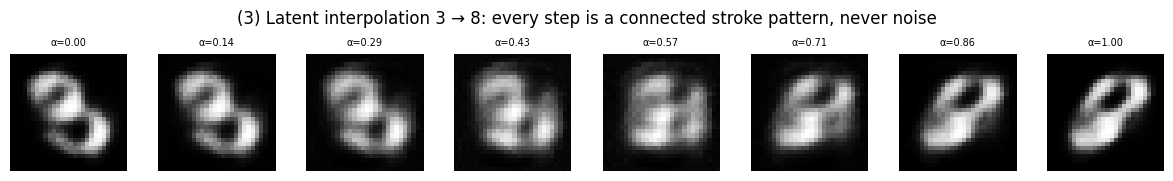

In [3]:
# WHAT/WHY: run the three standard latent-space operations on the model we
# just trained — reconstruction of unseen digits, novel samples from the
# prior, and a latent interpolation between a real 3 and a real 8.
test_ds = torchvision.datasets.MNIST('/tmp/mnist', train=False, transform=T.ToTensor())

# ── (1) Reconstructions of unseen test digits ─────────────────────────────
x_test = torch.stack([test_ds[i][0] for i in range(8)])
with torch.no_grad():
    recon, _, _ = model(x_test)
fig, axes = plt.subplots(2, 8, figsize=(12, 3.2))
for i in range(8):
    axes[0, i].imshow(x_test[i].squeeze(), cmap='gray'); axes[0, i].axis('off')
    axes[1, i].imshow(recon[i].squeeze(),  cmap='gray'); axes[1, i].axis('off')
axes[0, 0].set_title("real", loc='left'); axes[1, 0].set_title("recon", loc='left')
plt.suptitle("(1) Reconstructions of unseen test digits")
plt.tight_layout(); plt.show()

# ── (2) Novel samples: decode z ~ N(0, I) ─────────────────────────────────
with torch.no_grad():
    samples = model.decode(torch.randn(8, LATENT))
fig, axes = plt.subplots(1, 8, figsize=(12, 1.8))
for i, ax in enumerate(axes):
    ax.imshow(samples[i].squeeze(), cmap='gray'); ax.axis('off')
plt.suptitle("(2) Samples from the prior z ~ N(0, I): every one a stroke pattern, only some a readable digit")
plt.tight_layout(); plt.show()

# ── (3) Interpolation: straight line between a 3's and an 8's latent code ─
img_a = next(test_ds[i][0] for i in range(1000) if test_ds[i][1] == 3)
img_b = next(test_ds[i][0] for i in range(1000) if test_ds[i][1] == 8)
with torch.no_grad():
    z_a, _ = model.encode(img_a.unsqueeze(0))   # (1, 1, 28, 28) → latent mean
    z_b, _ = model.encode(img_b.unsqueeze(0))
    steps = torch.linspace(0, 1, 8)
    morphs = torch.cat([model.decode((1 - a) * z_a + a * z_b) for a in steps])
fig, axes = plt.subplots(1, 8, figsize=(12, 1.8))
for i, ax in enumerate(axes):
    ax.imshow(morphs[i].squeeze(), cmap='gray'); ax.axis('off')
    ax.set_title(f"α={steps[i]:.2f}", fontsize=7)
plt.suptitle("(3) Latent interpolation 3 → 8: every step is a connected stroke pattern, never noise")
plt.tight_layout(); plt.show()


## What the Latent Space Looks Like

Interpolation (3) worked because the path between two digits stays *inside* the region the
decoder knows. That is a property of the space itself, so the next figure draws it: every
test digit's latent mean, projected to two dimensions and coloured by its true class, with
the 3 → 8 path drawn through it.

latent means over 1500 test digits — mean -0.107, std 1.073   (target: 0 and 1 — that is what the KL term pulls toward)
these 2 directions carry 23% of the spread of a 16-D space — a flat shadow of the real thing


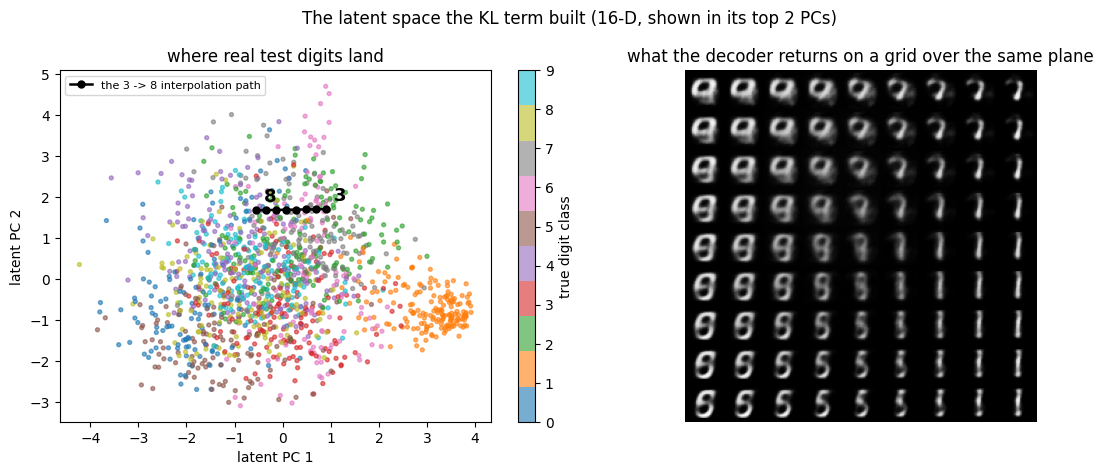

In [4]:
# WHAT/WHY: sampling and interpolation only work because the KL term made the
# latent space CONTINUOUS and roughly N(0, I). That is a claim about a 16-D
# space, so we look at it twice: (left) where real digits land, projected onto
# the two directions of greatest spread, with the 3 -> 8 path from the cell
# above drawn through them; (right) what the DECODER returns on a grid across
# that same plane — 81 decodes, no training.
n_show = 1500
X_lat  = torch.stack([test_ds[i][0] for i in range(n_show)])
y_lat  = np.array([test_ds[i][1] for i in range(n_show)])
with torch.no_grad():
    mu_all, _ = model.encode(X_lat)

# Is the aggregate latent actually near N(0, I)? Measure it, do not assume it.
print(f"latent means over {n_show} test digits — mean {mu_all.mean():.3f}, "
      f"std {mu_all.std():.3f}   (target: 0 and 1 — that is what the KL term pulls toward)")

# PCA by hand: centre, then project onto the two directions of greatest spread
mu_mean = mu_all.mean(0, keepdim=True)
mu_c    = mu_all - mu_mean
_, S, V = torch.pca_lowrank(mu_c, q=2)
P2      = (mu_c @ V).numpy()
z_path  = torch.cat([(1 - a) * z_a + a * z_b for a in steps])       # same path as (3)
path2   = ((z_path - mu_mean) @ V).numpy()
print(f"these 2 directions carry {100 * (S**2).sum().item() / (mu_c**2).sum().item():.0f}% "
      f"of the spread of a {LATENT}-D space — a flat shadow of the real thing")

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8))

# ── left: where the real digits' codes actually sit ───────────────────────
sc = axes[0].scatter(P2[:, 0], P2[:, 1], c=y_lat, cmap='tab10', s=8, alpha=0.6)
axes[0].plot(path2[:, 0], path2[:, 1], 'k-o', lw=1.8, ms=5, zorder=3,
             label="the 3 -> 8 interpolation path")
for lbl, pt in (("3", path2[0]), ("8", path2[-1])):
    axes[0].annotate(lbl, pt, fontsize=13, fontweight='bold', zorder=4,
                     xytext=(6, 6), textcoords='offset points')
plt.colorbar(sc, ax=axes[0], label="true digit class", ticks=range(10))
axes[0].set_xlabel("latent PC 1"); axes[0].set_ylabel("latent PC 2")
axes[0].set_title("where real test digits land")
axes[0].legend(loc='upper left', fontsize=8)

# ── right: decode a 9x9 grid across that same plane ───────────────────────
G  = 9
gx = np.linspace(*np.percentile(P2[:, 0], [2, 98]), G)
gy = np.linspace(*np.percentile(P2[:, 1], [2, 98]), G)
tiles = np.zeros((G * 28, G * 28))
with torch.no_grad():
    for r, b in enumerate(gy[::-1]):                    # top row = high PC 2
        coords = torch.tensor(np.stack([[a, b] for a in gx]), dtype=torch.float32)
        imgs   = model.decode(mu_mean + coords @ V.T).squeeze(1).numpy()
        for c_, im in enumerate(imgs):
            tiles[r * 28:(r + 1) * 28, c_ * 28:(c_ + 1) * 28] = im
axes[1].imshow(tiles, cmap='gray', vmin=0, vmax=1); axes[1].axis('off')
axes[1].set_title("what the decoder returns on a grid over the same plane")

plt.suptitle("The latent space the KL term built (16-D, shown in its top 2 PCs)")
plt.tight_layout(); plt.show()


### 👁️ Read the figure

**Left — where real digits land.** The cloud is centred on the origin and about one unit
wide (the printed mean −0.107 and std 1.073 are the KL term doing its job), and it is one
connected mass with no holes. That, not class separation, is what makes the operations above
legal: any straight line you draw inside this cloud — such as the 3 → 8 path — passes only
through territory the decoder was trained on.

**Left, the honest part.** The classes are *not* separated. Only the 1s (orange, lower right)
pull clear of the crowd; everything else overlaps. A plain VAE gets no labels, so it has no
reason to sort digits into class regions — and note that two principal components carry only
23% of a 16-D space's spread, so this is a flat shadow, not the space itself. If you need
class control, you have to build it in — that is exactly what the conditional VAE in lesson
03 does.

**Right — the decoder over that same plane.** Every one of the 81 grid points decodes to
something digit-shaped, and neighbours look like neighbours: 9s slide into 7s across the top,
5s into 1s along the bottom. Cross-check the two panels: the orange 1s sit at high PC 1 and
low PC 2 on the left, and the bottom-right corner of the grid is full of 1s. No blank tiles,
no garbage tiles — **that continuity is the thing the KL term bought**, and it is why
sampling z ~ N(0, I) returns a digit instead of noise.

## 💬 Discuss

1. Reconstruction fell **235.8 → 109.5** while KL **rose 11.1 → 19.5** over six epochs. Why does the KL term *rise* during training rather than fall? What would you conclude if you saw it fall to near zero while reconstruction kept improving?
2. Stable Diffusion uses its VAE for 48× compression, not for generation — the generating is done by the diffusion model on top. Does that make the KL term more or less important there than here? Argue from what a diffusion model needs from its latent space.
3. Our reconstructions are visibly blurrier than the originals. Name one product where that blur is disqualifying and one where it is irrelevant — and say what property of the product decides it.


## 🌍 Real-World Worked Example — Anomaly Detection with a VAE

**Industry context:**
- **Manufacturing:** VAE-style models flag defective parts on assembly lines
- **Finance:** payment fraud systems score transactions by reconstruction error
- **Healthcare:** models of normal scans flag anomalous MRI images

We retrain the same architecture **only on the digit 0** ("normal" data), then score unseen digits by reconstruction error: 0s reconstruct well, 8s (never seen) reconstruct badly.


Epoch 0 — loss: 314.82


Epoch 5 — loss: 145.82


Epoch 10 — loss: 123.09



Reconstruction error — Normal (0): 0.0183  Anomaly (8): 0.0588
Higher error = anomaly flagged (same principle as production fraud detection)
threshold (mean + 2*sd of the normal class) = 0.0358
  anomalies caught: 49/50   false alarms: 3/42


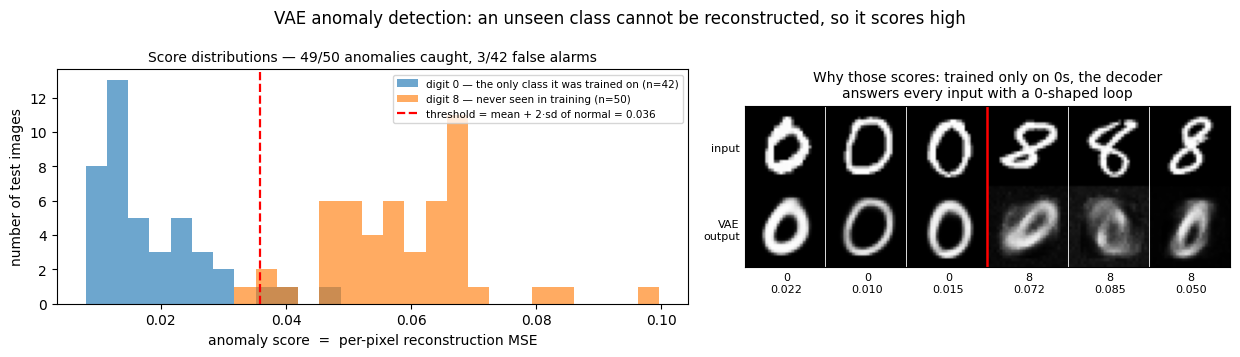

In [5]:
# WHAT/WHY: train a fresh VAE on ONLY digit 0, then use reconstruction error
# as an anomaly score — the unseen class (digit 8) scores much higher, and a
# simple threshold separates the two distributions. The figure shows both the
# score distributions AND the reconstructions that produced them.
torch.manual_seed(42)

# Train only on digit "0" (the "normal" class)
idx_0 = [i for i, (x, y) in enumerate(dataset) if y == 0][:2000]
normal_loader = torch.utils.data.DataLoader(
    torch.utils.data.Subset(dataset, idx_0), batch_size=64, shuffle=True)

anomaly_model = VAE()
opt = optim.Adam(anomaly_model.parameters(), lr=1e-3)

for epoch in range(15):
    total = 0
    for x, _ in normal_loader:
        recon, mu, lv = anomaly_model(x)
        recon_loss = nn.functional.binary_cross_entropy(recon, x, reduction='sum')
        kl_loss    = -0.5 * (1 + lv - mu.pow(2) - lv.exp()).sum()
        loss = recon_loss + 0.5 * kl_loss
        opt.zero_grad(); loss.backward(); opt.step()
        total += loss.item()
    if epoch % 5 == 0:
        print(f"Epoch {epoch} — loss: {total/len(idx_0):.2f}")

# ── Score unseen digits: class 0 (seen) vs class 8 (never seen) ───────────
anomaly_model.eval()
samples_0 = torch.stack([test_ds[i][0] for i in range(500)  if test_ds[i][1] == 0][:50])
samples_8 = torch.stack([test_ds[i][0] for i in range(1000) if test_ds[i][1] == 8][:50])

def recon_error(imgs):
    with torch.no_grad():
        recon, _, _ = anomaly_model(imgs)
        return nn.functional.mse_loss(recon, imgs, reduction='none').view(len(imgs), -1).mean(1)

err_0 = recon_error(samples_0).numpy()
err_8 = recon_error(samples_8).numpy()
print(f"\nReconstruction error — Normal (0): {err_0.mean():.4f}  Anomaly (8): {err_8.mean():.4f}")
print("Higher error = anomaly flagged (same principle as production fraud detection)")

# ── One figure, two halves: WHAT the detector scores, and WHY ─────────────
# left  = the two score distributions with the operating threshold on them
# right = the same detector's inputs and outputs, so you can see the cause:
#         a VAE that only ever saw 0s can only draw 0s.
thresh      = err_0.mean() + 2 * err_0.std()      # a standard 2-sigma rule
caught      = int((err_8 > thresh).sum())          # anomalies correctly flagged
false_alarm = int((err_0 > thresh).sum())          # normals wrongly flagged
print(f"threshold (mean + 2*sd of the normal class) = {thresh:.4f}")
print(f"  anomalies caught: {caught}/{len(err_8)}   false alarms: {false_alarm}/{len(err_0)}")

fig, (axh, axi) = plt.subplots(1, 2, figsize=(12.5, 3.6),
                               gridspec_kw={'width_ratios': [1.3, 1]})

bins = np.linspace(min(err_0.min(), err_8.min()), max(err_0.max(), err_8.max()), 28)
axh.hist(err_0, bins=bins, alpha=0.65, color='tab:blue',
         label=f"digit 0 — the only class it was trained on (n={len(err_0)})")
axh.hist(err_8, bins=bins, alpha=0.65, color='tab:orange',
         label=f"digit 8 — never seen in training (n={len(err_8)})")
axh.axvline(thresh, color='red', ls='--', lw=1.6,
            label=f"threshold = mean + 2·sd of normal = {thresh:.3f}")
axh.set_xlabel("anomaly score  =  per-pixel reconstruction MSE")
axh.set_ylabel("number of test images")
axh.set_title(f"Score distributions — {caught}/{len(err_8)} anomalies caught, "
              f"{false_alarm}/{len(err_0)} false alarms", fontsize=10)
axh.legend(fontsize=7.5, loc='upper right')

# ── right: the first three 0s and first three 8s (no cherry-picking) ──────
shown  = torch.cat([samples_0[:3], samples_8[:3]])
scores = np.concatenate([err_0[:3], err_8[:3]])
labels = ["0"] * 3 + ["8"] * 3
with torch.no_grad():
    shown_recon, _, _ = anomaly_model(shown)
tile = np.zeros((2 * 28, 6 * 28))
for j in range(6):
    tile[0:28,  j * 28:(j + 1) * 28] = shown[j].squeeze().numpy()
    tile[28:56, j * 28:(j + 1) * 28] = shown_recon[j].squeeze().numpy()
axi.imshow(tile, cmap='gray', vmin=0, vmax=1)
axi.set_yticks([14, 42]); axi.set_yticklabels(["input", "VAE\noutput"], fontsize=8)
axi.set_xticks([14 + 28 * j for j in range(6)])
axi.set_xticklabels([f"{labels[j]}\n{scores[j]:.3f}" for j in range(6)], fontsize=8)
axi.tick_params(length=0)
for x in range(28, 6 * 28, 28):
    axi.axvline(x - 0.5, color='white', lw=0.6)
axi.axvline(3 * 28 - 0.5, color='red', lw=1.8)      # 0s | 8s divider
axi.set_title("Why those scores: trained only on 0s, the decoder\nanswers every input with a 0-shaped loop", fontsize=10)

plt.suptitle("VAE anomaly detection: an unseen class cannot be reconstructed, so it scores high")
plt.tight_layout(); plt.show()


### 👁️ Read the figure

**Left — the two score distributions.** The blue histogram (digit 0, the only class this VAE
ever saw) piles up between 0.01 and 0.03. The orange histogram (digit 8, never seen) sits
shifted right of it, with its bulk between 0.045 and 0.07 and a tail out to 0.10. The red dashed line is the
operating threshold, set the cheap way: mean + 2·sd of the *normal* class only, which is all
you have in production because you do not get labelled anomalies in advance. At that
threshold 49 of 50 eights are caught and 3 of the 42 zeros are false alarms — and both errors
are visible in the picture: one orange count sits left of the red line, and blue counts sit
right of it. **The distributions separate, but they are not disjoint.** Any threshold you pick is a
trade: move the line left and you catch the last 8 but raise the false-alarm count.

**Right — why the scores come out that way.** The first three test 0s and the first three
test 8s (no selection), each with its own score under it. Top row is the input, bottom row is
what the VAE returned. The 0s come back as 0s, so their error is small. The 8s come back as
0-shaped ovals with the crossing smudged away — and the middle one barely holds a shape at all.
The decoder has no way to draw an 8, because nothing in its training set had that shape. That mismatch *is* the anomaly score. This is the
whole production pattern: **you never train on the anomaly; you train on normal and measure
surprise.**

## ⚠️ Where this breaks

**Per-pixel reconstruction loss is an averaging loss, and averaging is blur.** Given several plausible outputs the objective returns their mean. This is a property of the loss, not of training length: more epochs sharpen it slowly and never remove it. If you need sharp, you need a different objective — adversarial (Unit 1) or diffusion (example 04).

**Posterior collapse.** If the decoder is powerful enough, the optimiser can drive KL toward zero, the latent stops carrying information, and the VAE degenerates into an unconditional decoder. Watch the KL component every run: a near-zero KL with a good reconstruction is a broken VAE, not an excellent one.

**The ELBO is a lower bound, so VAE "likelihoods" are not comparable.** You cannot rank a VAE against an exact-likelihood model, and you cannot reliably rank two VAEs with different architectures, because the tightness of the bound differs.

**Cheaper alternative:** if you only ever need compression and reconstruction and will never sample, a plain autoencoder does that job better — no KL term fighting the reconstruction, and a lower reconstruction error for the same capacity.


## 📝 Summary

In this notebook, you implemented and verified the full VAE toolkit on images:
- The **architecture**: encoder → μ/log σ² heads → reparameterized z → decoder
- The **ELBO loss** with both components printed per epoch (reconstruction + KL)
- **Reconstruction, sampling, and interpolation** — all three demonstrated in figures above
- A production application: **anomaly detection**, where the unseen class produced clearly higher reconstruction errors (see printed averages and histogram)

**Next steps:** example 02 applies VAEs further (denoising); example 03 covers conditional VAEs and β-VAE; example 04 introduces diffusion models.


## 📚 References & Further Reading

**Papers:**
- Kingma & Welling (2014) — [Auto-Encoding Variational Bayes](https://arxiv.org/abs/1312.6114) *(foundational)*
- Doersch (2016) — [Tutorial on Variational Autoencoders](https://arxiv.org/abs/1606.05908)
- Higgins et al. (2017) — [β-VAE](https://openreview.net/forum?id=Sy2fchgcx)
- Vahdat & Kautz (2020) — [NVAE: A Deep Hierarchical Variational Autoencoder](https://arxiv.org/abs/2007.03898) *(how far the pure-VAE recipe scales)*

**State-of-the-Art:** Stable Diffusion runs its diffusion process inside a VAE's latent space — this architecture is a core component of modern image generators.
